# pagescan quickstart

An end-to-end tour of the [pagescan](https://github.com/7RPlus-GmbH/pagescan) API — single scans, batch processing, custom configuration, and debug visualisation.

This notebook generates its own synthetic demo image so it runs anywhere without external assets.

## Setup

```bash
pip install "pagescan[ml]" jupyter matplotlib
```

The `[ml]` extras enable the YOLO + HQ-SAM cascade. Without them, pagescan falls back to a legacy ONNX detection chain — both produce reasonable results.

In [1]:
import tempfile
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

import pagescan
from pagescan import ScanConfig, PRESET_FAST, PRESET_RAW, scan, scan_batch

print(f"pagescan {pagescan.__version__}")

WORK = Path(tempfile.mkdtemp(prefix="pagescan_quickstart_"))
print(f"Working directory: {WORK}")

pagescan 0.1.0
Working directory: /tmp/pagescan_quickstart_463hcjvw


## Generate a demo photo

We'll synthesise a phone photo of a document: white paper on a warm wood background, with some fake text. This matches the kind of input pagescan is tuned for.

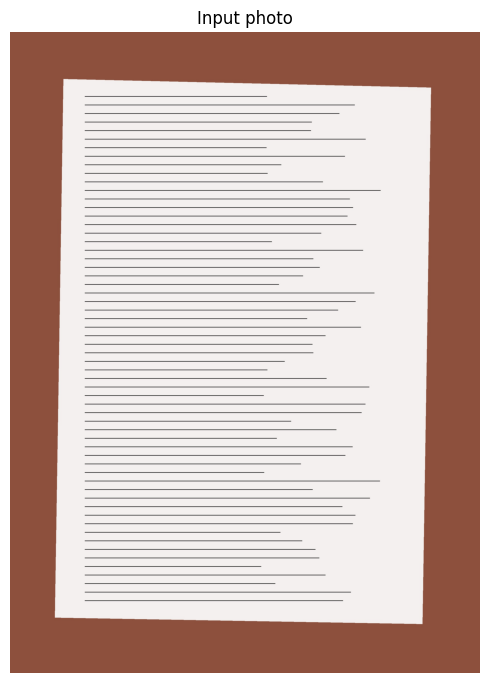

In [2]:
def make_demo_photo(path: Path, h: int = 3000, w: int = 2200) -> Path:
    img = np.zeros((h, w, 3), dtype=np.uint8)

    # Warm wood background (HSV: H~20, S~120, V~140 -> BGR equivalent)
    img[:] = (60, 80, 140)

    # Paper region (slightly inset, slight tilt)
    margin = 200
    paper_corners = np.array([
        [margin + 50, margin + 20],
        [w - margin - 30, margin + 60],
        [w - margin - 70, h - margin - 30],
        [margin + 10, h - margin - 60],
    ], dtype=np.int32)
    cv2.fillPoly(img, [paper_corners], (240, 240, 245))

    # Synthetic text lines
    rng = np.random.default_rng(42)
    for y in range(margin + 100, h - margin - 100, 40):
        x_end = margin + 150 + int(rng.integers(800, 1400))
        img[y : y + 3, margin + 150 : x_end] = (30, 30, 30)

    cv2.imwrite(str(path), img)
    return path


photo_path = make_demo_photo(WORK / "demo.jpg")

fig, ax = plt.subplots(figsize=(5, 7))
ax.imshow(cv2.cvtColor(cv2.imread(str(photo_path)), cv2.COLOR_BGR2RGB))
ax.set_title("Input photo")
ax.axis("off")
plt.tight_layout()

## 1. Single scan

The simplest call: photo in, PDF out. We use `PRESET_FAST` here to skip the (one-time) ML model download for the demo. In production, you'd typically use the defaults — see section 4 below.

In [3]:
pdf_path = WORK / "scan.pdf"

result = scan(str(photo_path), str(pdf_path), config=PRESET_FAST)

print("Success:    ", result["success"])
print("Output:     ", result["output_path"])
print("Quality:    ", f"{result['quality_score']:.2f}")
print("QA passed:  ", result["quality_passed"])
print("PDF size:   ", f"{Path(result['output_path']).stat().st_size / 1024:.1f} KB")

Success:     True
Output:      /tmp/pagescan_quickstart_463hcjvw/scan.pdf
Quality:     1.00
QA passed:   True
PDF size:    175.5 KB


The `result` dict tells you what happened:

- `success` — boolean
- `output_path` — path to the produced PDF
- `quality_score` — heuristic 0–1 confidence
- `quality_passed` — did the QA threshold get cleared
- `message` — human-readable description

In [4]:
import json
print(json.dumps({k: str(v) for k, v in result.items()}, indent=2))

{
  "success": "True",
  "quality_score": "0.9981176470588236",
  "quality_passed": "True",
  "message": "OK",
  "output_path": "/tmp/pagescan_quickstart_463hcjvw/scan.pdf"
}


## 2. Batch directory

`scan_batch` processes every image in an input directory, writing PDFs to an output directory. Parallelised across CPU cores by default — cap with `workers=N` if needed.

In [5]:
input_dir = WORK / "batch_in"
output_dir = WORK / "batch_out"
input_dir.mkdir(exist_ok=True)
output_dir.mkdir(exist_ok=True)

# Drop three copies of the demo photo into the input directory
for i in range(3):
    cv2.imwrite(str(input_dir / f"page_{i:02d}.jpg"), cv2.imread(str(photo_path)))

summary = scan_batch(str(input_dir), str(output_dir), config=PRESET_FAST, workers=1)

print("\nSummary:")
print(f"  Processed:   {summary['processed']}")
print(f"  Failed:      {summary['failed']}")
print(f"  Low quality: {summary['low_quality']}")
for pdf in sorted(output_dir.glob("*.pdf")):
    print(f"  {pdf.name}: {pdf.stat().st_size / 1024:.1f} KB")


[1/3] page_00.jpg



[2/3] page_01.jpg



[3/3] page_02.jpg



Processed: 3
Low quality: 0
Failed: 0

Summary:
  Processed:   3
  Failed:      0
  Low quality: 0
  page_00.pdf: 179.1 KB
  page_01.pdf: 179.1 KB
  page_02.pdf: 179.1 KB


## 3. Inspect the rendered output

Let's render the PDF back to an image so we can compare input vs output side-by-side. We use `pdf2image` if available, otherwise just pull the corrected image directly from the pipeline.

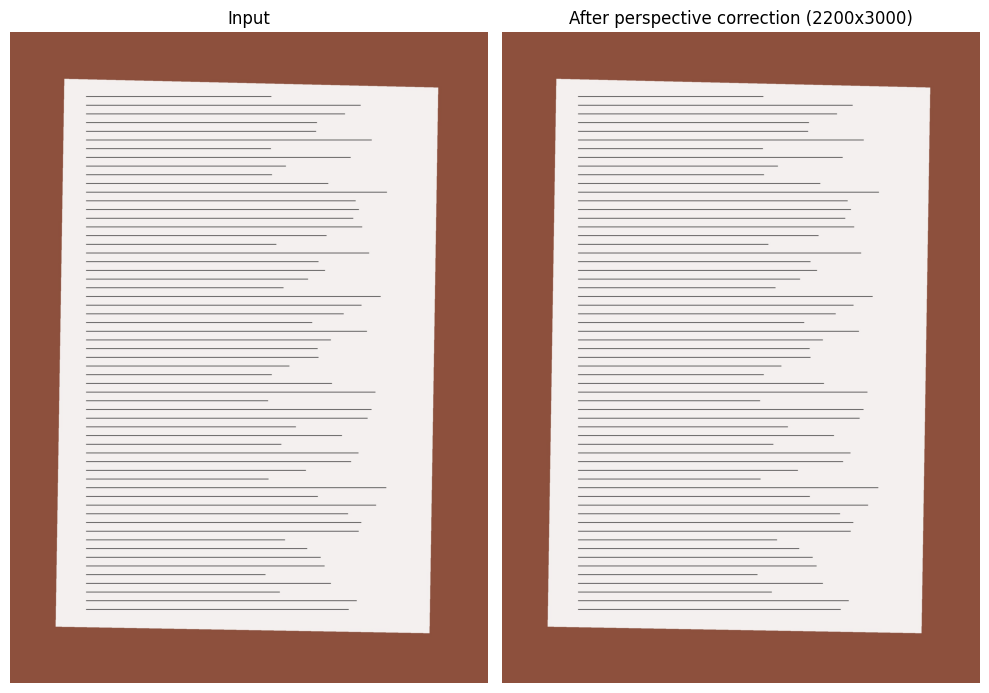

In [6]:
# Pull the corrected image directly from the pipeline (skip PDF roundtrip)
from pagescan.corners import detect_corners
from pagescan.transform import perspective_transform

raw = cv2.imread(str(photo_path))
corners, _ = detect_corners(raw, ScanConfig(use_ml=False))

if corners is not None:
    corrected = perspective_transform(raw, corners)
else:
    corrected = raw  # fall back; contour path used in scan()

fig, axes = plt.subplots(1, 2, figsize=(10, 7))
axes[0].imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB))
axes[0].set_title("Input")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"After perspective correction ({corrected.shape[1]}x{corrected.shape[0]})")
axes[1].axis("off")
plt.tight_layout()

## 4. Custom configuration

All knobs live on the `ScanConfig` dataclass. The most common adjustments:

In [7]:
# US Letter at 300 DPI, higher JPEG quality, no auto-rotation
letter_config = ScanConfig(
    output_width=2550,
    output_height=3300,
    jpeg_quality=80,
    auto_orient=False,
    use_ml=False,  # skip ML for this demo
)
scan(str(photo_path), str(WORK / "letter.pdf"), config=letter_config)

# Raw mode: just crop + perspective, no enhancement / WB / shadow removal
scan(str(photo_path), str(WORK / "raw.pdf"), config=PRESET_RAW)

# List everything we've produced
for pdf in sorted(WORK.glob("*.pdf")):
    print(f"{pdf.name:20s} {pdf.stat().st_size / 1024:6.1f} KB")

/home/thinkbook14g7arp/anaconda3/envs/docu_py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/thinkbook14g7arp/anaconda3/envs/docu_py312/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/thinkbook14g7arp/anaconda3/envs/docu_py312/lib/python3.12/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/thinkbook14g7arp/anaconda3/envs/docu_py312/lib/python3.12/site-packages/segment_anything_hq/modeling/tiny_vit_sam.py:662: UserWarning: Overwriting tiny_vit_5m_224 in registry with segment_anything_hq.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_mode

letter.pdf            239.4 KB
raw.pdf               206.4 KB
scan.pdf              175.5 KB


### Tuning the over-crop guard

The single most common knob to adjust is `min_doc_coverage` — the minimum fraction of the frame that an accepted document must occupy. Default is 5%. Raise it if pagescan keeps cropping into the document interior; lower it if your documents legitimately occupy a small portion of the frame.

In [8]:
# Stricter over-crop guard
strict = ScanConfig(use_ml=False, min_doc_coverage=0.20)
scan(str(photo_path), str(WORK / "strict.pdf"), config=strict)
print("Done: stricter over-crop guard (20% minimum coverage)")

Done: stricter over-crop guard (20% minimum coverage)


## 5. Debug mode

Set `debug=True` and pagescan writes every intermediate stage as an image to `debug_dir`. Use this when diagnosing bad scans.

Debug artefacts in /tmp/pagescan_quickstart_463hcjvw/debug:
  enhanced_color.jpg
  result.jpg


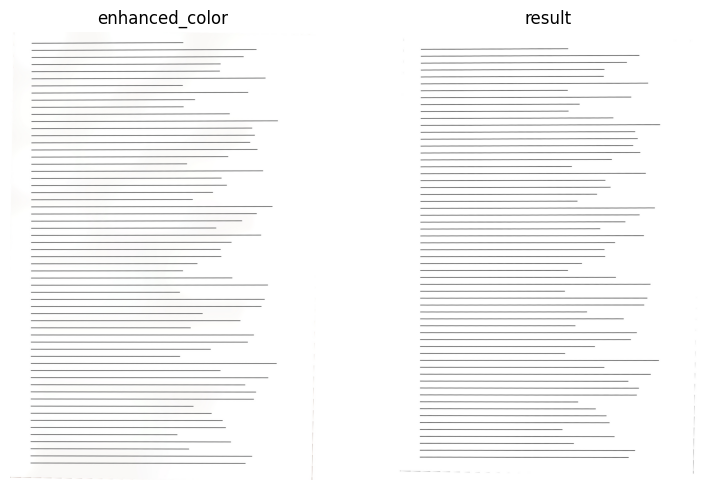

In [9]:
debug_dir = WORK / "debug"
debug_config = ScanConfig(
    use_ml=False,
    debug=True,
    debug_dir=str(debug_dir),
)
scan(str(photo_path), str(WORK / "debug_out.pdf"), config=debug_config)

debug_files = sorted(debug_dir.glob("*.jpg"))
print(f"Debug artefacts in {debug_dir}:")
for f in debug_files:
    print(f"  {f.name}")

# Show them in a grid
if debug_files:
    n = len(debug_files)
    cols = min(n, 3)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 5 * rows))
    axes = np.atleast_2d(axes).flatten()
    for ax, f in zip(axes, debug_files):
        img = cv2.imread(str(f))
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f.stem)
        ax.axis("off")
    for ax in axes[len(debug_files):]:
        ax.axis("off")
    plt.tight_layout()

## 6. Using the full ML cascade

By default, `scan()` uses the YOLO + HQ-SAM cascade for the sharpest corner detection. We disabled it above (`use_ml=False`) to keep this notebook self-contained, but if you have the `[ml]` extras installed, the cell below will pull the cascade weights (~50 MB YOLO, ~360 MB HQ-SAM checkpoint) from Hugging Face on first run and use them.

In [10]:
try:
    import torch  # noqa: F401
    import segment_anything_hq  # noqa: F401
    HAS_ML = True
except ImportError:
    HAS_ML = False

if HAS_ML:
    result = scan(str(photo_path), str(WORK / "cascade.pdf"))
    print("Cascade scan succeeded.")
    print("  Quality: ", f"{result['quality_score']:.2f}")
    print("  PDF size:", f"{Path(result['output_path']).stat().st_size / 1024:.1f} KB")
else:
    print("`[ml]` extras not installed. To enable the cascade:")
    print("    pip install 'pagescan[ml]'")
    print("On first run, pagescan downloads weights from")
    print("    https://huggingface.co/7rplus/pagescan-weights")

Cascade scan succeeded.
  Quality:  1.00
  PDF size: 178.6 KB


## Equivalents from the CLI

Everything in this notebook has a command-line equivalent:

```bash
# Section 1: single scan
pagescan photo.jpg output.pdf

# Section 2: batch
pagescan --batch --input-dir photos/ --output-dir scans/ --workers 4

# Section 4: raw mode (no enhancement)
pagescan photo.jpg out.pdf --raw

# Section 5: debug mode
pagescan photo.jpg out.pdf --debug --debug-dir ./debug/
```

Run `pagescan --help` for the complete flag list.

## Next steps

- **[Configuration reference](https://7rplus-gmbh.github.io/pagescan/config.html)** — every `ScanConfig` field, defaults, and a tuning guide.
- **[Architecture](https://7rplus-gmbh.github.io/pagescan/architecture.html)** — how the cascade actually works.
- **[Troubleshooting](https://7rplus-gmbh.github.io/pagescan/troubleshooting.html)** — common failures and fixes.
- **[API reference](https://7rplus-gmbh.github.io/pagescan/api.html)** — full module-by-module API.